In [4]:
import wandb
wandb.login(key="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")

socket.send() raised exception.
socket.send() raised exception.


Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x769b113c0fe0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 7698b85f3f20, raw_cell="import wandb
wandb.login(key="wandb_v1_00HD4MQuIUQ.." transformed_cell="import wandb
wandb.login(key="wandb_v1_00HD4MQuIUQ.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Bliuchaosong/media/E/sj/Code/aortic_regurgitation/optimize_pose.ipynb#X32sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


False

socket.send() raised exception.
socket.send() raised exception.


Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x769b113c0fe0>> (for post_run_cell), with arguments args (<ExecutionResult object at 7698b85f27e0, execution_count=4 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7698b85f3f20, raw_cell="import wandb
wandb.login(key="wandb_v1_00HD4MQuIUQ.." transformed_cell="import wandb
wandb.login(key="wandb_v1_00HD4MQuIUQ.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Bliuchaosong/media/E/sj/Code/aortic_regurgitation/optimize_pose.ipynb#X32sdnNjb2RlLXJlbW90ZQ%3D%3D> result=False>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

In [5]:

from typing import Literal, Optional, TypeVar, Any
from dataclasses import dataclass
from math import radians
from pathlib import Path
from enum import IntEnum

import numpy as np
from numpy import ndarray

import torch
from torch import Tensor
from torch import nn
from torch.utils.dlpack import from_dlpack as dlpack2tensor
from torch.utils.dlpack import to_dlpack as tensor2dlpack   #type: ignore
from torchio import LabelMap, ScalarImage, Subject
import torchvision.transforms as T

import cupy as cp
from cupyx.scipy.ndimage import center_of_mass, binary_dilation

import nibabel as nib
from nibabel.loadsave import load as nib_load
from nibabel.nifti1 import Nifti1Image

from diffdrr.drr import DRR, convert
from diffdrr.visualization import plot_img_and_mask, plot_drr, plot_mask
from diffdrr.metrics import NormalizedCrossCorrelation2d
from diffdrr.registration import Registration

from matplotlib import pyplot as plt
import pandas as pd
from tqdm import tqdm
import wandb
from easydict import EasyDict
import yaml
from PIL import Image


MM = float | int
Pixel = int
MMPerPixel = float | int

Degree = float | int
DegreePerSec = float | int
Radian = float | int
Angle = TypeVar("Angle", Degree, Radian)
type Rot[Angle] = tuple[Angle, Angle, Angle]

Sec = float | int
Point: tuple[float, float, float]


class LabelID(IntEnum):
    AO = 1
    LV = 2
    # AO = 1
    # LA = 2
    # RA = 3
    # LVM = 4
    # LV = 5
    # RV = 6
    # PV = 7

@dataclass
class CArmGeometry:
    sdd: MM             # Source to detector distance
    sod: MM             # Source to object distance
    height: Pixel       # Height of image
    delx: MMPerPixel    # Pixel size in x direction
    _width: Pixel | None = None         # Width of image, default to height
    _dely: MMPerPixel | None = None     # Pixel size in y direction, default to delx
    x0: MM = 0.0             # detector principal point x-offset
    y0: MM = 0.0             # detector principal point y-offset
    
    def __post_init__(self):
        if self._width is None:
            self._width = self.height
        if self._dely is None:
            self._dely = self.delx
    
    @property
    def width(self) -> Pixel:
        assert self._width is not None
        return self._width
    
    @property
    def dely(self) -> MMPerPixel:
        assert self._dely is not None
        return self._dely


@dataclass
class DrrSetting:
    patch_size: int = 256
    orientation_type: Literal["AP", "PA"]|None = "AP"
    parameterization: str = "euler_angles"  # representation of rotation
    convention: str = "ZXY"                 # rotation axis sequence, internal rotation
    mask_to_channels: bool = True           # project masks to different label


def get_reorientation(
        orientation_type: Optional[Literal["AP", "PA"]] = "AP"
) -> torch.Tensor:
    # Frame-of-reference change
    if orientation_type == "AP":
        # Rotates the C-arm about the x-axis by 90 degrees
        reorient = torch.tensor(
            [
                [1, 0, 0, 0],
                [0, 0, -1, 0],
                [0, 1, 0, 0],
                [0, 0, 0, 1],
            ],
            dtype=torch.float32,
        )
    elif orientation_type == "PA":
        # Rotates the C-arm about the x-axis by 90 degrees
        # Reverses the direction of the y-axis
        reorient = torch.tensor(
            [
                [1, 0, 0, 0],
                [0, 0, 1, 0],
                [0, 1, 0, 0],
                [0, 0, 0, 1],
            ],
            dtype=torch.float32,
        )
    elif orientation_type is None:
        # Identity transform
        reorient = torch.tensor(
            [
                [1, 0, 0, 0],
                [0, 1, 0, 0],
                [0, 0, 1, 0],
                [0, 0, 0, 1],
            ],
            dtype=torch.float32,
        )
    else:
        raise ValueError(f"Unrecognized orientation {orientation_type}")
    return reorient


def recenter(
    original_affine: ndarray,
    center_voxel: tuple[int, int, int]
) -> ndarray:
    """get the affine that set the center of the image to the given center_voxel
    """
    B = original_affine[:3, :3]
    new_t = -(B @ np.array(center_voxel))
    T = np.eye(4)
    T[:3, :3] = B
    T[:3, 3] = new_t
    return T


def get_coronary_centering_affine(label: Tensor, volume_affine: ndarray) -> ndarray:
    """
    Compute an affine transform that recenters the heart region in world coordinates for CTA
    Args:
        label (Tensor): Binary label mask of shape (1, 1, D, H, W).
        volume_affine (ndarray): Original volume affine matrix of shape (4, 4).

    Returns:
        ndarray: New affine matrix that centers the label's structure in world space.
    """
    ref_label = (label > 0) & (label!=LabelID.AO)
    with cp.cuda.Device(label.device.index):
        label_center = center_of_mass(cp.from_dlpack(tensor2dlpack(ref_label.squeeze().to(label.device)))) # type: ignore
        label_center = (int(label_center[0]), int(label_center[1]), int(label_center[2]))
        return recenter(volume_affine, label_center)


def pre_load(file: Path) -> tuple[Nifti1Image, ndarray]:
    image_nii = nib_load(file)
    assert isinstance(image_nii, Nifti1Image)
    affine = image_nii.affine if image_nii.affine is not None else np.eye(4)
    return image_nii, affine


def load_nifti(file: Path, is_label: bool = False) -> tuple[Tensor, ndarray]:
    """load nifti file as torch tensor (shape: 1, 1, D, H, W) and return its affine matrix"""
    img, affine = pre_load(file)
    tensor = torch.from_numpy(img.get_fdata())
    if is_label:
        tensor = tensor.round().to(torch.uint8)
    else:
        tensor = tensor.to(torch.float32)
    tensor = tensor[None][None]  # add batch and channel dim
    return tensor, affine


def adjust_iodine_contrast(volume: Tensor, label: Tensor) -> Tensor:
    res = volume.clone()
    # CTA造影剂区域恢复正常血液（与水接近，为0）
    threshold_mask = (volume > 150) & (volume < 400)
    res[(label > 0) | threshold_mask ] = 0.
    
    # 体外仪器的线
    res[res > 1500] = res.min()
    
    res[(res > -150) & (res < 0.)] = 0.
    res[res < -150] = res.min()
    
    res = 0.0001 * (res/1000 + 1).clamp(min=0., max=2.)
    res_max = res.max()
    res /= res_max
    res = res ** 2
    res *= res_max
    return res


def get_drr(
    img_path: Path,
    seg_path: Path,
    whole_heart_label_path: Path,
    geom: CArmGeometry,
    device: torch.device,
    config: DrrSetting = DrrSetting()
) -> DRR:
    volume, volume_affine = load_nifti(img_path)
    label, _ = load_nifti(seg_path, is_label=True)
    whole_heart_label, _ = load_nifti(whole_heart_label_path, is_label=True)
    volume = volume.to(device)
    label = label.to(device)
    whole_heart_label = whole_heart_label.to(device)
    whole_heart_label[whole_heart_label != 2] = 0
    affine = get_coronary_centering_affine(whole_heart_label, volume_affine)
    volume = adjust_iodine_contrast(volume, label)
    
    assert volume.dim() >= 3
    w, h, d = volume.shape[-3:]
    shape = (1, w, h, d)
    
    subject = Subject(
        volume=ScalarImage(tensor=volume.float().reshape(*shape).to(device), affine=affine),
        mask=LabelMap(tensor=label.reshape(*shape).to(device), affine=affine),
        reorient = get_reorientation("AP"),    # type: ignore
        density = ScalarImage(tensor=volume.float().reshape(*shape).to(device), affine=affine),
        fiducials = None,   #type: ignore
    )
    
    drr = DRR(
        subject     =   subject,
        sdd         =   geom.sdd,
        height      =   geom.height,
        width       =   geom.width,
        delx        =   geom.delx,
        dely        =   geom.dely,
        x0          =   geom.x0,
        y0          =   geom.y0,
        patch_size  =   config.patch_size,
        renderer    =   "trilinear",
        checkpoint_gradients=True
    ).to(device)
    
    return drr


def pose_from_carm(sod: MM, tx: MM, ty: MM, alpha: Radian, beta: Radian, gamma: Radian) -> tuple[Tensor, Tensor]:
    rot = torch.tensor([[alpha, beta, gamma]])
    xyz = torch.tensor([[tx, sod, ty]])
    pose = convert(rot, xyz, parameterization="euler_angles", convention="ZXY")
    rotations, translations = pose.convert("euler_angles", "ZXY")
    return rotations, translations


def run(reg: Registration) -> tuple[Tensor, Tensor]:
    proj: Tensor = reg(mask_to_channels=True)
    img = proj.sum(dim=1, keepdim=True)
    img = torch.exp(-img)
    img = img - img.min()
    img = img / img.max()
    
    label = proj.squeeze()[[0, LabelID.AO, LabelID.LV]]
    label[0] = 0
    label = (label > 0).to(torch.uint8).squeeze().argmax(0)
    return img, label


def train(
    reg: Registration,
    gt_img: Tensor,
    optim: torch.optim.Optimizer,
    loss_fn: nn.Module,
    n_itrs: int,
    val_intervals: int
):
    # Initialize an optimizer with different learning rates
    # for rotations and translations since they have different scales
    wandb.watch(reg.drr)
    
    # record init value
    def get_record(iter_: int, reg_: Registration, loss_: Tensor) -> dict[str, int|float]:
        alpha, beta, gamma = reg_.rotation.squeeze().tolist()
        bx, by, bz = reg_.translation.squeeze().tolist()
        return {
            "itr": iter_, "loss": loss_.item(),
            "alpha": alpha, "beta": beta, "gamma": gamma,
            "bx": bx, "by": by, "bz": bz
        }
    
    img, label = run(reg)
    record = get_record(0, reg, loss_fn(gt_img, img))
    records = [list(record.values())]
    for itr in (pbar := tqdm(range(n_itrs), ncols=100)):
        optim.zero_grad()
        img, label = run(reg)
        loss: Tensor = loss_fn(gt_img, img)
        loss.backward()
        optim.step()
        
        pbar.set_description(f"loss = {loss.item():06f}")
        record = get_record(itr, reg, loss)
        records.append(list(record.values()))
        wandb.log(record)
        
        if itr >= val_intervals and itr % val_intervals == 0:
            masks={
                "labels": {
                    'mask_data': label,
                    "class_labels": {
                        1: "AO",
                        2: "LV"
                    }
                }
            }
            wandb.log({
                "drr_image": wandb.Image(img.squeeze()[None], mode="L", masks=masks),
                "gt_image": wandb.Image(gt_img.squeeze()[None], mode="L", masks=masks),
            })

    df = pd.DataFrame(records, columns=list(record.keys()))
    return df


def load_config(path: Path) -> EasyDict:
    with open(path, 'r') as f:
        cfg = yaml.safe_load(f)
    return EasyDict(cfg)

socket.send() raised exception.
socket.send() raised exception.


Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x769b113c0fe0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 7698b8543a40, raw_cell="
from typing import Literal, Optional, TypeVar, An.." transformed_cell="from typing import Literal, Optional, TypeVar, Any.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Bliuchaosong/media/E/sj/Code/aortic_regurgitation/optimize_pose.ipynb#W0sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

socket.send() raised exception.
socket.send() raised exception.


Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x769b113c0fe0>> (for post_run_cell), with arguments args (<ExecutionResult object at 7698b864b8f0, execution_count=5 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 7698b8543a40, raw_cell="
from typing import Literal, Optional, TypeVar, An.." transformed_cell="from typing import Literal, Optional, TypeVar, Any.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Bliuchaosong/media/E/sj/Code/aortic_regurgitation/optimize_pose.ipynb#W0sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

In [6]:

config_path = Path("/media/E/sj/Code/aortic_regurgitation/config/base_config.yaml")
cfg: Any = load_config(config_path)

# load config and init wandb
wandb.init(
    project="aortic_regurgitation",
    config=cfg,
)

# init DRR with geometry
geom = CArmGeometry(
    sdd     =   cfg.geom.sdd,
    sod     =   cfg.geom.sod,
    height  =   cfg.geom.height,
    delx    =   cfg.geom.delx
)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
drr = get_drr(
    Path(cfg.data.img_path),
    Path(cfg.data.seg_path),
    Path(cfg.data.whole_heart_label_path),
    geom, 
    device
).train()

# init pose
rotations, translations = pose_from_carm(
    geom.sod, 0., 0., 
    radians(cfg.init_pose.alpha), radians(cfg.init_pose.beta), 0.
)

# init registration for training
reg = Registration(
    drr,
    rotations.to(device).clone(),
    translations.to(device).clone(),
    parameterization="euler_angles",
    convention="ZXY",
)

if cfg.optimizer.type == "sgd":
    optim_cls = torch.optim.SGD
elif cfg.optimizer.type == "adam":
    optim_cls = torch.optim.Adam
else:
    raise NotImplementedError
optim = torch.optim.SGD(
    [
        {"params": [reg._rotation], "lr": cfg.optimizer.lr_rotations},
        {"params": [reg._translation], "lr": cfg.optimizer.lr_translations},
    ],
    **cfg.optimizer.init_args
)

if cfg.loss.type == "ncc":
    loss_fn_cls = NormalizedCrossCorrelation2d
else:
    raise NotImplementedError
loss_fn = loss_fn_cls(**cfg.loss.init_args).to(device)


img_2d = T.ToTensor()(
    Image.open(cfg.data.image_2d_path).convert("L")
).to(device)


socket.send() raised exception.
socket.send() raised exception.


Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x769b113c0fe0>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 7698b826a510, raw_cell="
config_path = Path("/media/E/sj/Code/aortic_regur.." transformed_cell="config_path = Path("/media/E/sj/Code/aortic_regurg.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Bliuchaosong/media/E/sj/Code/aortic_regurgitation/optimize_pose.ipynb#W1sdnNjb2RlLXJlbW90ZQ%3D%3D>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

socket.send() raised exception.
socket.send() raised exception.


BrokenPipeError: [Errno 32] Broken pipe

socket.send() raised exception.
socket.send() raised exception.


Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x769b113c0fe0>> (for post_run_cell), with arguments args (<ExecutionResult object at 7698b826a390, execution_count=6 error_before_exec=None error_in_exec=[Errno 32] Broken pipe info=<ExecutionInfo object at 7698b826a510, raw_cell="
config_path = Path("/media/E/sj/Code/aortic_regur.." transformed_cell="config_path = Path("/media/E/sj/Code/aortic_regurg.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Bliuchaosong/media/E/sj/Code/aortic_regurgitation/optimize_pose.ipynb#W1sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


BrokenPipeError: [Errno 32] Broken pipe

In [ ]:

train(
    reg     =   reg,
    gt_img  =   img_2d[None],
    optim   =   optim,
    loss_fn =   loss_fn,
    n_itrs  =   cfg.train.n_itrs,
    val_intervals = cfg.train.val_interval
)

loss = 0.737190:  44%|███████████████████▌                        | 222/500 [03:22<04:14,  1.09it/s]


KeyboardInterrupt: 

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x769b113c0fe0>> (for post_run_cell), with arguments args (<ExecutionResult object at 769b0ed83bf0, execution_count=3 error_before_exec=None error_in_exec= info=<ExecutionInfo object at 769b0ed83d70, raw_cell="
train(
    reg     =   reg,
    gt_img  =   img_2.." transformed_cell="train(
    reg     =   reg,
    gt_img  =   img_2d.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell://ssh-remote%2Bliuchaosong/media/E/sj/Code/aortic_regurgitation/optimize_pose.ipynb#X31sdnNjb2RlLXJlbW90ZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

In [ ]:
img_2d.shape

torch.Size([1, 512, 512])

In [ ]:
# proj = reg(mask_to_channels=True)
# img = proj.sum(dim=1, keepdim=True)
# label = proj.clone().squeeze()[[0, LabelID.AO, LabelID.LV]]
# label[0] = 0
# label = (label > 0).to(torch.uint8).squeeze().argmax(0)
# plt.imshow(label.detach().cpu().numpy())

torch.Size([1, 3, 512, 512])

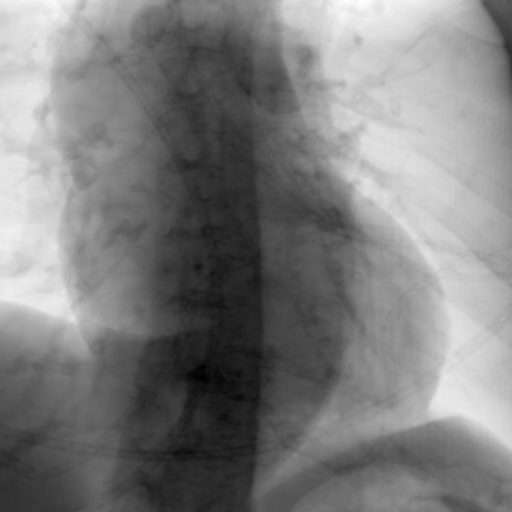

In [ ]:
# wimg = img.clone()
# wimg = torch.exp(-wimg)
# wimg -= wimg.min()
# wimg /= wimg.max()
# wimg = wandb.Image(
#     wimg.squeeze()[None], 
#     mode="L",
#     masks={
#         "labels": {
#             'mask_data': label,
#             "class_label": {
#                 0: "bg",
#                 1: "AO",
#                 2: "LV"
#             }
#         }
#     }
# )
# wimg.image